# Soft-SENSE testbench

Quick A/B bench for soft SENSE: an adjoint check on the full encoding operator, an
`M=1` equivalence check against the existing single-map `Sense`, and the reduced-FOV
fold experiment where soft SENSE actually earns its keep.

`SoftSense` is imported from `operators.sense`, `espirit_soft` from `physics.smaps`.

In [1]:
import os
os.chdir('/scratch/ee2178/ImMAP')

import torch

from operators import Mask, Sense, FFT2D, Identity
from operators.sense import SoftSense
from operators.fourier import fftc, ifftc
from physics.mask import make_acc_mask
from physics.smaps import espirit, espirit_soft
from datasets.fastmri.common import load_knee_data
from visualization.image import plot_image
from solvers import cg
from utils.tensor import truncate

device = 'cuda'

/home/ee2178/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


## Testbench helpers

In [2]:
def adjoint_test(E, x_like, y_like):
    """<E x, y> == <x, E.H y> ; returns relative error."""
    x = torch.randn_like(x_like)
    y = torch.randn_like(y_like)
    lhs = (E(x) * y.conj()).sum()
    rhs = (x * E.H(y).conj()).sum()
    return (lhs - rhs).abs() / (lhs.abs() + 1e-12)


def softsense_cg(y, smaps_soft, mask, l=0.01, max_iter=500, tol=1e-3):
    """CG soft-SENSE (Tikhonov, no denoiser). Returns (x_cg, tol_reached, E)."""
    E = Mask(mask) @ FFT2D() @ SoftSense(smaps_soft)

    def A(x, E=E, l=l):
        return E.normal(x) + l * x

    b = E.H(y)                                  # (B, M, 1, Nx, Ny)
    x_cg, tol_reached = cg(A, b, max_iter=max_iter, tol=tol, verbose=False)
    return x_cg, tol_reached, E


def combine_rss(x_cg):
    """Magnitude (RSS) combine over the M component axis -> (B, 1, Nx, Ny)."""
    return x_cg.abs().pow(2).sum(dim=1).sqrt()

## 1) Load data + accelerated mask (full FOV)

In [14]:
# fname = "file1000264.h5"
fname = None
kspace, smaps, knee_mask, gnd_truth = load_knee_data(
    kspace_fname=fname, slice_idx=15, device=device
)
mask = make_acc_mask(shape=kspace[0, 0].shape, accel=6, acs_lines=20, device=device)
y = mask * kspace
B, C, Nx, Ny = kspace.shape

Loading slice 15 from /home/ee2178/scratch/ee2178/datasets/fastmri/knee/multicoil_val/file1001668.h5


## 2) Operator correctness

Adjoint test on the full soft encoding chain, plus an `M=1` equivalence check: feed the
*same* ground-truth maps into both `Sense` and `SoftSense` and confirm the normal
operators agree. This isolates the operator from map estimation.

In [15]:
E_soft1 = Mask(mask) @ FFT2D() @ SoftSense(smaps[:, None])   # (B,1,C,Nx,Ny)
E_sense = Mask(mask) @ FFT2D() @ Sense(smaps)

# adjoint test on the full soft encoding chain
img_like = torch.randn(B, 1, 1, Nx, Ny, dtype=kspace.dtype, device=device)
err = adjoint_test(E_soft1, img_like, y)
print(f"[adjoint] full-chain relative error: {err.item():.2e}   (want < 1e-5)")

# M=1 equivalence: normal-operator outputs should match after squeezing the
# extra singleton map axis.
xs = torch.randn(B, 1, Nx, Ny, dtype=kspace.dtype, device=device)
out_sense = E_sense.normal(xs)                       # (B,1,Nx,Ny)
out_soft1 = E_soft1.normal(xs[:, None]).squeeze(1)   # (B,1,Nx,Ny)
rel = (out_soft1 - out_sense).norm() / (out_sense.norm() + 1e-12)
print(f"[M=1 equiv] ||soft1 - sense|| / ||sense||: {rel.item():.2e}   (want < 1e-6)")

[adjoint] full-chain relative error: 3.55e-07   (want < 1e-5)
[M=1 equiv] ||soft1 - sense|| / ||sense||: 0.00e+00   (want < 1e-6)


## 3) Soft-SENSE estimation + recon (full FOV)

Sanity case. With a full FOV a single map already explains the data, so `M=2` should
leave the second map nearly empty and the recon should match plain SENSE.

[support] per-map nonzero fraction: [0.607005774974823, 0.0]
[cg] tol_reached=True


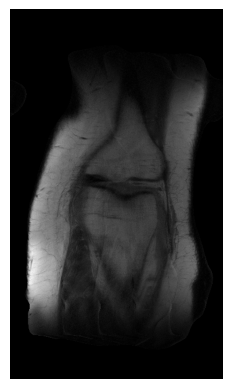

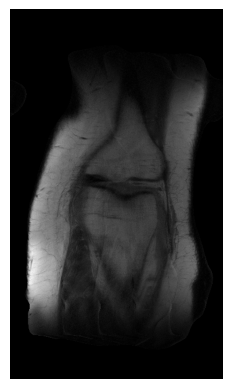

In [16]:
smaps_soft = espirit_soft(
    y, acs_size=(20, 20), kernel_size=8,
    thresh_rowspace=0.001, thresh_eig=0.995, num_maps=2,
)
smaps_soft = torch.flip(smaps_soft, dims=(-2, -1))   # same flip you apply to espirit

# how much support does each map carry? (fraction of nonzero voxels)
support = (smaps_soft.abs().sum(dim=2) > 0).float().mean(dim=(-2, -1))  # (B, M)
print(f"[support] per-map nonzero fraction: {support[0].tolist()}")

x_cg, tol_reached, _ = softsense_cg(y, smaps_soft, mask, l=0.01)
print(f"[cg] tol_reached={tol_reached}")
plot_image(x_cg[:, 0])              # component 0 = the reconstruction
plot_image(combine_rss(x_cg))       # RSS-combined (matches comp 0 when map2 empty)

[cg] tol_reached=True


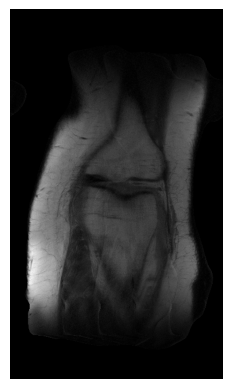

In [17]:
# Compare with standard SENSE reconstruction
x_cg, tol_reached, _ = softsense_cg(y, smaps_soft[:, 0:1], mask, l=1e-2)
print(f"[cg] tol_reached={tol_reached}")
plot_image(x_cg[:, 0])              # component 0 = the reconstruction

## 4) The real test: reduced-FOV fold

Truncating the readout FOV makes the object fold; a single map can't represent it
(central artifact, Fig. 9), two maps can. We compare `M=1` vs `M=2` head to head.
`thresh_eig` is dropped to 0.8 so the genuine second map isn't truncated.

In [6]:
Y = ifftc(y, dim=2, mode="ortho", real=False)
trunc_start, trunc_end = 100, 500
Y_trunc = truncate(Y, trunc_start, trunc_end, dim=2)
y_trunc = fftc(Y_trunc, dim=2, mode="ortho", real=False)
mask_trunc = truncate(mask, trunc_start, trunc_end, dim=2)

smaps_fold = espirit_soft(
    y_trunc, acs_size=(20, 20), kernel_size=8,
    thresh_rowspace=0.01, thresh_eig=0.8, num_maps=2,
)
smaps_fold = torch.flip(smaps_fold, dims=(-2, -1))

support = (smaps_fold.abs().sum(dim=2) > 0).float().mean(dim=(-2, -1))
print(f"[fold support] per-map nonzero fraction: {support[0].tolist()}  "
      f"(expect map 2 to occupy the folded region)")

[fold support] per-map nonzero fraction: [0.7763978242874146, 0.05469758063554764]  (expect map 2 to occupy the folded region)


[fold M=1] tol_reached=True


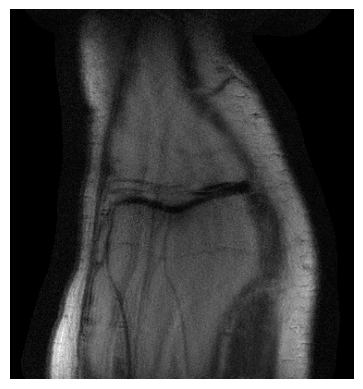

In [7]:
# M = 1 : single-map recon (should show the fold artifact)
x1, t1, _ = softsense_cg(y_trunc, smaps_fold[:, :1], mask_trunc, l=0.01)
print(f"[fold M=1] tol_reached={t1}")
plot_image(x1[:, 0])

[fold M=2] tol_reached=True


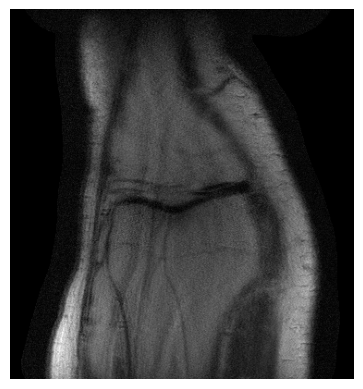

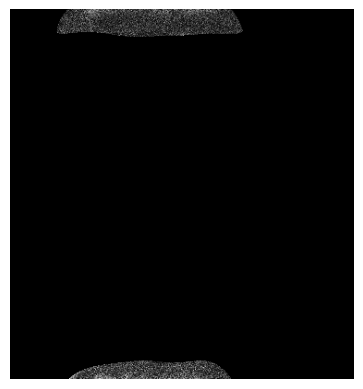

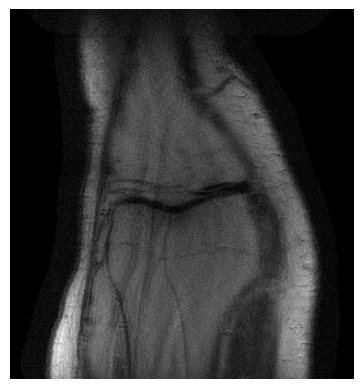

In [8]:
# M = 2 : soft-SENSE recon (component 0 should be artifact-free)
x2, t2, _ = softsense_cg(y_trunc, smaps_fold, mask_trunc, l=0.01)
print(f"[fold M=2] tol_reached={t2}")
plot_image(x2[:, 0])            # de-folded reconstruction
plot_image(x2[:, 1])            # second component: the folded-in content
plot_image(combine_rss(x2))     # RSS combine if you want both components

In [ ]:
# Now, for a measurement kspace vs simulated kspace experiment. 